# pipeline_versiones10: LiNGAM y resolucion de red

Este notebook agrega una comparacion por resolucion para los tres metodos principales del trabajo:
Pearson, Graphical Lasso y LiNGAM. La corrida base 100x100 se mantiene como referencia directa entre metodos. La nueva corrida 7x7 agrega las senales ROI del atlas Schaefer 100 en las 7 redes Yeo/Schaefer y recalcula los tres metodos en esa resolucion.

La idea metodologica es simple: si LiNGAM cambia al pasar de 100 ROIs a 7 redes, necesitamos saber si el cambio es propio de LiNGAM o si tambien aparece en Pearson y Graphical Lasso. Por eso el analisis 7x7 se implementa para los tres metodos.

Convencion para LiNGAM: `matriz[i, j]` se lee como influencia dirigida estimada desde la red/ROI `i` hacia la red/ROI `j`. La interpretacion sigue siendo prudente por las limitaciones temporales y hemodinamicas de la senal BOLD, pero LiNGAM se trata aqui como uno de los tres metodos principales del contraste.


## 0. Configuracion general

El notebook reutiliza la corrida base ya generada en `resultados/pipeline_schaefer_100_all_valid_100rois_tp146`. No vuelve a parcelar NIfTI ni modifica las matrices 100x100. Las salidas nuevas se guardan en `resultados/pipeline_versiones10_lingam_resolucion`.


In [15]:
from __future__ import annotations

from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

NOTEBOOK_ROOT = Path.cwd().resolve()
SCRIPT_DIR = NOTEBOOK_ROOT / "script"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from conectividad import correlacion, graphical_lasso, lingam, vectorizar
from pipeline_abide import evaluate_classifier, limpiar_numericos

BASE_RESULTS = NOTEBOOK_ROOT / "resultados" / "pipeline_schaefer_100_all_valid_100rois_tp146"
PHENOTYPE_CSV = NOTEBOOK_ROOT / "data" / "ABIDE_pcp" / "Phenotypic_V1_0b_preprocessed1.csv"
OUT_V10 = NOTEBOOK_ROOT / "resultados" / "pipeline_versiones10_lingam_resolucion"

FIG_DIR = OUT_V10 / "figures"
TABLE_DIR = OUT_V10 / "tables"
MATRIX_DIR = OUT_V10 / "matrices_7redes"
FEATURE_DIR = OUT_V10 / "features_7redes"

for path in [OUT_V10, FIG_DIR, TABLE_DIR, MATRIX_DIR, FEATURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

NETWORK_ORDER = [
    "Vis",
    "SomMot",
    "DorsAttn",
    "SalVentAttn",
    "Limbic",
    "Cont",
    "Default",
]

NETWORK_LABELS = {
    "Vis": "Visual",
    "SomMot": "Somatomotora",
    "DorsAttn": "Atencion dorsal",
    "SalVentAttn": "Saliencia/ventral",
    "Limbic": "Limbica",
    "Cont": "Control",
    "Default": "Modo defecto",
}

METHODS_V10 = {
    "pearson": {"label": "Pearson", "symmetric": True},
    "graphical_lasso": {"label": "Graphical Lasso", "symmetric": True},
    "lingam": {"label": "LiNGAM", "symmetric": False},
}

CLASSIFIERS_V10 = ["svm", "rf"]
CV_SPLITS = 5
CV_STRATEGY = "group_site"
RANDOM_STATE = 42
LINGAM_RANDOM_STATE = 42
LINGAM_MAX_ITER = 1000
GRAPHICAL_LASSO_ALPHA_7 = 0.5
GRAPHICAL_LASSO_MAX_ITER = 500
USE_CACHE = True

# Dejar en None para usar los 723 sujetos de la corrida base.
# Para probar rapido, usar por ejemplo RUN_SUBJECT_LIMIT = 30.
RUN_SUBJECT_LIMIT = None

print(f"Raiz notebook: {NOTEBOOK_ROOT}")
print(f"Corrida base: {BASE_RESULTS}")
print(f"Salidas v10: {OUT_V10}")


Raiz notebook: C:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega
Corrida base: C:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_schaefer_100_all_valid_100rois_tp146
Salidas v10: C:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones10_lingam_resolucion


## 1. Cargar cohorte y nombres ROI

La matriz 100x100 usa cada ROI Schaefer como nodo. La matriz 7x7 no es equivalente: promedia las senales de las ROIs que pertenecen a la misma red funcional y usa cada red como nodo. Gana estabilidad e interpretabilidad a costa de perder detalle regional.


In [16]:
def roi_network(roi_name: str) -> str:
    parts = str(roi_name).split("_")
    if len(parts) >= 3 and parts[0] == "7Networks" and parts[1] in {"LH", "RH"}:
        return parts[2]
    return "unknown"


def read_first_roi_names(base_results: Path, n_rois: int = 100) -> list[str]:
    parcel_root = base_results / "parcelacion_atlas"
    for metadata_path in sorted(parcel_root.glob("*/roi_metadata.json")):
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        roi_names = metadata.get("roi_names", [])
        if isinstance(roi_names, list) and len(roi_names) >= n_rois:
            return [str(name) for name in roi_names[:n_rois]]
    raise FileNotFoundError("No se encontraron roi_names en parcelacion_atlas/*/roi_metadata.json")


def load_manifest(base_results: Path, limit: int | None = None) -> pd.DataFrame:
    path = base_results / "sujetos_incluidos.csv"
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}")
    manifest = pd.read_csv(path)
    required = {"file_id", "label", "diagnosis", "site", "n_timepoints", "n_rois"}
    missing = sorted(required - set(manifest.columns))
    if missing:
        raise ValueError(f"Faltan columnas en sujetos_incluidos.csv: {missing}")
    manifest = manifest.copy()
    manifest["file_id"] = manifest["file_id"].astype(str)
    manifest["label"] = manifest["label"].astype(int)
    manifest["site"] = manifest["site"].astype(str)
    manifest["group"] = np.where(manifest["label"] == 1, "TEA", "Control")
    manifest = manifest.sort_values("file_id").reset_index(drop=True)
    if limit is not None:
        manifest = manifest.head(int(limit)).copy()
    return manifest


manifest = load_manifest(BASE_RESULTS, RUN_SUBJECT_LIMIT)
roi_names_100 = read_first_roi_names(BASE_RESULTS, 100)
roi_networks_100 = [roi_network(name) for name in roi_names_100]

roi_network_map = pd.DataFrame(
    {
        "roi_index": np.arange(len(roi_names_100)),
        "roi_index_1based": np.arange(1, len(roi_names_100) + 1),
        "roi_name": roi_names_100,
        "network": roi_networks_100,
        "network_label": [NETWORK_LABELS.get(network, network) for network in roi_networks_100],
    }
)
roi_network_map.to_csv(TABLE_DIR / "roi_a_red_schaefer100.csv", index=False)

network_counts = (
    roi_network_map.groupby(["network", "network_label"], as_index=False)
    .size()
    .rename(columns={"size": "n_rois"})
)
network_counts["network"] = pd.Categorical(network_counts["network"], NETWORK_ORDER, ordered=True)
network_counts = network_counts.sort_values("network").reset_index(drop=True)

cohort_summary = pd.DataFrame(
    [
        {
            "n_subjects": len(manifest),
            "n_tea": int((manifest["label"] == 1).sum()),
            "n_control": int((manifest["label"] == 0).sum()),
            "n_sites": int(manifest["site"].nunique()),
            "min_timepoints": int(manifest["n_timepoints"].min()),
            "max_timepoints": int(manifest["n_timepoints"].max()),
            "n_rois_base": int(manifest["n_rois"].mode().iloc[0]),
        }
    ]
)
cohort_summary.to_csv(TABLE_DIR / "cohorte_v10_resumen.csv", index=False)
network_counts.to_csv(TABLE_DIR / "schaefer100_rois_por_red.csv", index=False)

display(cohort_summary)
display(network_counts)


,n_subjects,n_tea,n_control,n_sites,min_timepoints,max_timepoints,n_rois_base
0,723,329,394,17,146,316,100


,network,network_label,n_rois
0,Vis,Visual,17
1,SomMot,Somatomotora,14
2,DorsAttn,Atencion dorsal,15
3,SalVentAttn,Saliencia/ventral,12
4,Limbic,Limbica,5
5,Cont,Control,13
6,Default,Modo defecto,24


## 2. Funciones para construir matrices 7x7

Para cada sujeto se cargan las 100 senales ROI z-score ya cacheadas. Luego se promedia por red Schaefer/Yeo y se vuelve a estandarizar cada senal de red. Con esas 7 senales se recalculan Pearson, Graphical Lasso y LiNGAM.


In [17]:
def standardize_columns(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mean = np.nanmean(x, axis=0, keepdims=True)
    std = np.nanstd(x, axis=0, keepdims=True)
    std = np.where(std < 1e-12, 1.0, std)
    z = (x - mean) / std
    return np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)


def load_roi_signals_100(file_id: str) -> np.ndarray:
    path = BASE_RESULTS / "filtrado_zscore" / f"{file_id}_roi_signals_z.npy"
    if not path.exists():
        raise FileNotFoundError(f"No existe cache ROI: {path}")
    x = np.asarray(np.load(path), dtype=float)
    if x.ndim != 2:
        raise ValueError(f"{path} no tiene shape 2D: {x.shape}")
    if x.shape[1] < len(roi_names_100):
        raise ValueError(f"{path} tiene {x.shape[1]} ROIs, se esperaban {len(roi_names_100)}")
    return x[:, : len(roi_names_100)]


def aggregate_to_7_networks(signals_100: np.ndarray) -> tuple[np.ndarray, dict[str, int]]:
    signals_100 = np.asarray(signals_100, dtype=float)
    columns = []
    counts = {}
    for network in NETWORK_ORDER:
        idx = [i for i, roi_network_name in enumerate(roi_networks_100) if roi_network_name == network]
        if not idx:
            raise ValueError(f"No hay ROIs para la red {network}")
        counts[network] = len(idx)
        columns.append(np.nanmean(signals_100[:, idx], axis=1))
    signals_7 = np.column_stack(columns)
    return standardize_columns(signals_7), counts


def matrix_cache_signature(file_id: str, method: str, n_timepoints: int) -> dict[str, object]:
    return {
        "pipeline_version": "v10",
        "source": "filtrado_zscore_schaefer100",
        "file_id": str(file_id),
        "method": method,
        "resolution": "schaefer_7_networks",
        "network_order": NETWORK_ORDER,
        "roi_names_100": roi_names_100,
        "n_timepoints": int(n_timepoints),
        "graphical_lasso_alpha_7": float(GRAPHICAL_LASSO_ALPHA_7),
        "lingam_random_state": int(LINGAM_RANDOM_STATE),
    }


def meta_matches(meta_path: Path, signature: dict[str, object]) -> bool:
    if not meta_path.exists():
        return False
    try:
        return json.loads(meta_path.read_text(encoding="utf-8")) == signature
    except Exception:
        return False


def compute_matrix_7(signals_7: np.ndarray, method: str) -> tuple[np.ndarray, dict[str, object]]:
    meta: dict[str, object] = {}
    with redirect_stdout(StringIO()):
        if method == "pearson":
            matrix = correlacion(signals_7)
            np.fill_diagonal(matrix, 1.0)
        elif method == "graphical_lasso":
            matrix, alpha_used = graphical_lasso(
                signals_7,
                cv=None,
                max_iter=GRAPHICAL_LASSO_MAX_ITER,
                alpha=GRAPHICAL_LASSO_ALPHA_7,
            )
            meta["alpha_used"] = float(alpha_used)
        elif method == "lingam":
            matrix, raw_matrix, causal_order = lingam(
                signals_7,
                max_iter=LINGAM_MAX_ITER,
                random_state=LINGAM_RANDOM_STATE,
            )
            meta["causal_order"] = [int(i) for i in causal_order]
            meta["raw_max_abs"] = float(np.max(np.abs(raw_matrix))) if raw_matrix.size else 0.0
        else:
            raise ValueError(f"Metodo no soportado en v10: {method}")

    matrix = np.asarray(matrix, dtype=float)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)

    if METHODS_V10[method]["symmetric"]:
        matrix = (matrix + matrix.T) / 2.0
        np.fill_diagonal(matrix, 1.0)
    else:
        np.fill_diagonal(matrix, 0.0)

    if matrix.shape != (len(NETWORK_ORDER), len(NETWORK_ORDER)):
        raise ValueError(f"{method}: matriz 7x7 con shape inesperado {matrix.shape}")
    if not np.isfinite(matrix).all():
        raise ValueError(f"{method}: matriz contiene NaN/inf")
    return matrix.astype(np.float32), meta


def matrix_values(matrix: np.ndarray, method: str) -> np.ndarray:
    n = matrix.shape[0]
    if METHODS_V10[method]["symmetric"]:
        return matrix[np.triu_indices(n, k=1)]
    return matrix[~np.eye(n, dtype=bool)]


def summarize_matrix(matrix: np.ndarray, method: str) -> dict[str, float | int]:
    values = matrix_values(matrix, method)
    nonzero = np.abs(values) > 1e-12
    return {
        "n_features": int(values.size),
        "n_nonzero": int(nonzero.sum()),
        "density": float(nonzero.mean()) if values.size else np.nan,
        "mean": float(np.mean(values)) if values.size else np.nan,
        "std": float(np.std(values)) if values.size else np.nan,
        "min": float(np.min(values)) if values.size else np.nan,
        "max": float(np.max(values)) if values.size else np.nan,
        "abs_mean": float(np.mean(np.abs(values))) if values.size else np.nan,
        "abs_p95": float(np.percentile(np.abs(values), 95)) if values.size else np.nan,
        "diag_max_abs": float(np.max(np.abs(np.diag(matrix)))),
        "symmetry_max_abs_diff": float(np.max(np.abs(matrix - matrix.T))),
    }


## 3. Calcular y cachear matrices 7x7

Esta celda crea matrices nuevas en `resultados/pipeline_versiones10_lingam_resolucion/matrices_7redes`. Si ya existen y la firma coincide, las reutiliza. La salida `X_*_7redes.npy` queda lista para clasificacion supervisada.


In [18]:
def build_7network_datasets(manifest: pd.DataFrame) -> tuple[dict[str, dict[str, object]], pd.DataFrame, pd.DataFrame]:
    datasets: dict[str, dict[str, object]] = {
        method: {"matrices": [], "vectors": [], "y": [], "matrix_paths": []}
        for method in METHODS_V10
    }
    matrix_summary_rows = []
    signal_summary_rows = []

    for pos, row in enumerate(manifest.itertuples(index=False), start=1):
        file_id = str(row.file_id)
        label = int(row.label)
        signals_100 = load_roi_signals_100(file_id)
        signals_7, counts = aggregate_to_7_networks(signals_100)

        signal_summary = {
            "file_id": file_id,
            "label": label,
            "diagnosis": str(row.diagnosis),
            "site": str(row.site),
            "n_timepoints": int(signals_7.shape[0]),
            "n_networks": int(signals_7.shape[1]),
        }
        signal_summary.update({f"n_rois_{network}": int(counts[network]) for network in NETWORK_ORDER})
        signal_summary_rows.append(signal_summary)

        for method in METHODS_V10:
            method_dir = MATRIX_DIR / method
            method_dir.mkdir(parents=True, exist_ok=True)
            matrix_path = method_dir / f"{file_id}_{method}_7redes.npy"
            meta_path = matrix_path.with_suffix(".meta.json")
            signature = matrix_cache_signature(file_id, method, signals_7.shape[0])

            if USE_CACHE and matrix_path.exists() and meta_matches(meta_path, signature):
                matrix = np.asarray(np.load(matrix_path), dtype=np.float32)
            else:
                matrix, method_meta = compute_matrix_7(signals_7, method)
                np.save(matrix_path, matrix)
                meta = {**signature, **method_meta}
                meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

            vector = vectorizar(matrix, simetrica=METHODS_V10[method]["symmetric"])
            vector = np.nan_to_num(np.asarray(vector, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

            datasets[method]["matrices"].append(matrix)
            datasets[method]["vectors"].append(vector)
            datasets[method]["y"].append(label)
            datasets[method]["matrix_paths"].append(matrix_path)

            summary = summarize_matrix(matrix, method)
            matrix_summary_rows.append(
                {
                    "file_id": file_id,
                    "label": label,
                    "diagnosis": str(row.diagnosis),
                    "site": str(row.site),
                    "method": method,
                    "method_label": METHODS_V10[method]["label"],
                    "resolution": "7 redes",
                    "n_timepoints": int(signals_7.shape[0]),
                    "n_nodes": int(signals_7.shape[1]),
                    **summary,
                }
            )

        if pos == 1 or pos % 25 == 0 or pos == len(manifest):
            print(f"{pos:03d}/{len(manifest)} sujetos procesados para matrices 7x7")

    for method in METHODS_V10:
        matrices = limpiar_numericos(np.asarray(datasets[method]["matrices"], dtype=np.float32), f"matrices_{method}_7redes")
        X = limpiar_numericos(np.asarray(datasets[method]["vectors"], dtype=np.float32), f"X_{method}_7redes")
        y = np.asarray(datasets[method]["y"], dtype=int)
        datasets[method]["matrices"] = matrices
        datasets[method]["X"] = X
        datasets[method]["y"] = y

        np.save(FEATURE_DIR / f"X_{method}_7redes.npy", X)
        np.save(FEATURE_DIR / f"y_{method}_7redes.npy", y)
        np.save(FEATURE_DIR / f"matrices_{method}_7redes.npy", matrices)

        feature_map_rows = []
        n = len(NETWORK_ORDER)
        if METHODS_V10[method]["symmetric"]:
            pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
        else:
            pairs = [(i, j) for i in range(n) for j in range(n) if i != j]
        for feature_index, (i, j) in enumerate(pairs):
            feature_map_rows.append(
                {
                    "feature_index": feature_index,
                    "method": method,
                    "directed": not METHODS_V10[method]["symmetric"],
                    "network_origen_idx": i,
                    "network_destino_idx": j,
                    "network_origen": NETWORK_ORDER[i],
                    "network_destino": NETWORK_ORDER[j],
                    "network_origen_label": NETWORK_LABELS[NETWORK_ORDER[i]],
                    "network_destino_label": NETWORK_LABELS[NETWORK_ORDER[j]],
                }
            )
        pd.DataFrame(feature_map_rows).to_csv(FEATURE_DIR / f"{method}_7redes_feature_map.csv", index=False)
        print(f"{method}: X={X.shape}, y={y.shape}, matrices={matrices.shape}")

    matrix_summary = pd.DataFrame(matrix_summary_rows)
    signal_summary = pd.DataFrame(signal_summary_rows)
    matrix_summary.to_csv(TABLE_DIR / "resumen_matrices_7redes.csv", index=False)
    signal_summary.to_csv(TABLE_DIR / "resumen_senales_7redes.csv", index=False)
    return datasets, matrix_summary, signal_summary


datasets_7, matrix_summary_7, signal_summary_7 = build_7network_datasets(manifest)

display(
    matrix_summary_7.groupby(["method", "method_label"], as_index=False)
    .agg(
        n_subjects=("file_id", "nunique"),
        n_features=("n_features", "first"),
        density_mean=("density", "mean"),
        abs_mean_mean=("abs_mean", "mean"),
        abs_p95_mean=("abs_p95", "mean"),
    )
)


001/723 sujetos procesados para matrices 7x7
025/723 sujetos procesados para matrices 7x7
050/723 sujetos procesados para matrices 7x7
075/723 sujetos procesados para matrices 7x7
100/723 sujetos procesados para matrices 7x7
125/723 sujetos procesados para matrices 7x7
150/723 sujetos procesados para matrices 7x7
175/723 sujetos procesados para matrices 7x7
200/723 sujetos procesados para matrices 7x7
225/723 sujetos procesados para matrices 7x7
250/723 sujetos procesados para matrices 7x7
275/723 sujetos procesados para matrices 7x7
300/723 sujetos procesados para matrices 7x7
325/723 sujetos procesados para matrices 7x7
350/723 sujetos procesados para matrices 7x7
375/723 sujetos procesados para matrices 7x7
400/723 sujetos procesados para matrices 7x7
425/723 sujetos procesados para matrices 7x7
450/723 sujetos procesados para matrices 7x7
475/723 sujetos procesados para matrices 7x7
500/723 sujetos procesados para matrices 7x7
525/723 sujetos procesados para matrices 7x7
550/723 su

,method,method_label,n_subjects,n_features,density_mean,abs_mean_mean,abs_p95_mean
0,graphical_lasso,Graphical Lasso,723,21,0.513206,0.063739,0.204223
1,lingam,LiNGAM,723,42,0.359119,0.185496,0.786101
2,pearson,Pearson,723,21,1.000000,0.526657,0.750563


## 4. Clasificacion supervisada con SVM y Random Forest

Se usan los mismos clasificadores principales del pipeline base: SVM con kernel RBF y Random Forest. La validacion cruzada mantiene la estrategia agrupada por sitio (`group_site`) para que la comparacion con 100x100 sea lo mas directa posible.


In [19]:
def evaluate_7network_classification(datasets_7: dict[str, dict[str, object]], manifest: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = []
    fold_rows = []
    prediction_rows = []
    groups = manifest["site"].astype(str).to_numpy()
    file_ids = manifest["file_id"].astype(str).to_numpy()

    for method, data in datasets_7.items():
        X = np.asarray(data["X"], dtype=np.float32)
        y = np.asarray(data["y"], dtype=int)
        for classifier in CLASSIFIERS_V10:
            result = evaluate_classifier(
                X,
                y,
                classifier,
                n_splits=CV_SPLITS,
                cv_strategy=CV_STRATEGY,
                groups=groups,
                random_state=RANDOM_STATE,
            )
            row = {
                "method": method,
                "method_label": METHODS_V10[method]["label"],
                "classifier": classifier,
                "resolution": "7 redes",
                "n_nodes": len(NETWORK_ORDER),
                "n_features": int(X.shape[1]),
                "n_subjects": int(len(y)),
                "n_tea": int((y == 1).sum()),
                "n_control": int((y == 0).sum()),
                "n_splits": int(result["n_splits"]),
                "cv_strategy": result["cv_strategy"],
            }
            for metric in ["accuracy", "balanced_accuracy", "auc", "f1", "precision", "recall", "specificity"]:
                row[metric] = float(result[metric])
                row[f"{metric}_fold_mean"] = float(result[f"{metric}_mean"])
                row[f"{metric}_fold_std"] = float(result[f"{metric}_std"])
            rows.append(row)

            for fold_row in result["fold_metrics"]:
                fold_rows.append({"method": method, "classifier": classifier, "resolution": "7 redes", **fold_row})

            for file_id, y_true, y_score, y_pred, site in zip(
                file_ids,
                result["y_true"],
                result["y_score"],
                result["y_pred"],
                groups,
            ):
                prediction_rows.append(
                    {
                        "file_id": file_id,
                        "site": site,
                        "method": method,
                        "classifier": classifier,
                        "resolution": "7 redes",
                        "y_true": int(y_true),
                        "y_score_asd": float(y_score),
                        "y_pred": int(y_pred),
                    }
                )

    results = pd.DataFrame(rows).sort_values(["method", "classifier"]).reset_index(drop=True)
    folds = pd.DataFrame(fold_rows)
    predictions = pd.DataFrame(prediction_rows)

    results.to_csv(TABLE_DIR / "clasificacion_7redes_resultados.csv", index=False)
    folds.to_csv(TABLE_DIR / "clasificacion_7redes_metricas_por_fold.csv", index=False)
    predictions.to_csv(TABLE_DIR / "clasificacion_7redes_predicciones_por_sujeto.csv", index=False)
    return results, folds, predictions


classification_7, folds_7, predictions_7 = evaluate_7network_classification(datasets_7, manifest)
display(
    classification_7[
        [
            "method_label",
            "classifier",
            "n_features",
            "balanced_accuracy",
            "auc",
            "recall",
            "specificity",
            "f1",
        ]
    ].sort_values(["balanced_accuracy", "auc"], ascending=False)
)


,method_label,classifier,n_features,balanced_accuracy,auc,recall,specificity,f1
5,Pearson,svm,21,0.551097,0.580856,0.419453,0.682741,0.466216
2,LiNGAM,rf,42,0.534677,0.534607,0.343465,0.725888,0.410909
0,Graphical Lasso,rf,21,0.531575,0.541257,0.398176,0.664975,0.442568
4,Pearson,rf,21,0.525230,0.555039,0.398176,0.652284,0.438861
1,Graphical Lasso,svm,21,0.505080,0.531595,0.246201,0.763959,0.322068
3,LiNGAM,svm,42,0.495583,0.457065,0.100304,0.890863,0.162963


## 5. Comparar 100 ROIs versus 7 redes

Esta comparacion responde directamente si el cambio de resolucion ayuda solo a LiNGAM o si tambien modifica Pearson y Graphical Lasso. Si LiNGAM mejora en 7 redes, eso se interpreta junto con los resultados de los otros dos metodos.


In [20]:
def load_base_classification_results() -> pd.DataFrame:
    path = BASE_RESULTS / "tabla_comparativa_resultados.csv"
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}")
    base = pd.read_csv(path)
    base = base[base["method"].isin(METHODS_V10)].copy()
    if "n_tea" not in base.columns and "n_asd" in base.columns:
        base["n_tea"] = base["n_asd"]
    if "n_control" not in base.columns and "n_controls" in base.columns:
        base["n_control"] = base["n_controls"]
    base["method_label"] = base["method"].map(lambda method: METHODS_V10[method]["label"])
    base["resolution"] = "100 ROIs"
    base["n_nodes"] = 100
    return base


base_classification = load_base_classification_results()
comparison_cols = [
    "method",
    "method_label",
    "classifier",
    "resolution",
    "n_nodes",
    "n_features",
    "n_subjects",
    "n_tea",
    "n_control",
    "balanced_accuracy",
    "auc",
    "recall",
    "specificity",
    "f1",
    "precision",
    "accuracy",
]

comparison = pd.concat(
    [
        base_classification[comparison_cols],
        classification_7[comparison_cols],
    ],
    ignore_index=True,
)
comparison["resolution"] = pd.Categorical(comparison["resolution"], ["100 ROIs", "7 redes"], ordered=True)
comparison = comparison.sort_values(["method", "classifier", "resolution"]).reset_index(drop=True)
comparison.to_csv(TABLE_DIR / "comparacion_clasificacion_100rois_vs_7redes.csv", index=False)

display(
    comparison[
        [
            "method_label",
            "classifier",
            "resolution",
            "n_features",
            "balanced_accuracy",
            "auc",
            "recall",
            "specificity",
            "f1",
        ]
    ]
)


,method_label,classifier,resolution,n_features,balanced_accuracy,auc,recall,specificity,f1
0,Graphical Lasso,rf,100 ROIs,4950,0.585940,0.685869,0.349544,0.822335,0.447471
1,Graphical Lasso,rf,7 redes,21,0.531575,0.541257,0.398176,0.664975,0.442568
2,Graphical Lasso,svm,100 ROIs,4950,0.540304,0.593465,0.550152,0.530457,0.520863
3,Graphical Lasso,svm,7 redes,21,0.505080,0.531595,0.246201,0.763959,0.322068
4,LiNGAM,rf,100 ROIs,9900,0.461211,0.437624,0.206687,0.715736,0.267191
5,LiNGAM,rf,7 redes,42,0.534677,0.534607,0.343465,0.725888,0.410909
6,LiNGAM,svm,100 ROIs,9900,0.499186,0.442805,0.051672,0.946701,0.092643
7,LiNGAM,svm,7 redes,42,0.495583,0.457065,0.100304,0.890863,0.162963
8,Pearson,rf,100 ROIs,4950,0.595278,0.650039,0.401216,0.789340,0.485294
9,Pearson,rf,7 redes,21,0.525230,0.555039,0.398176,0.652284,0.438861


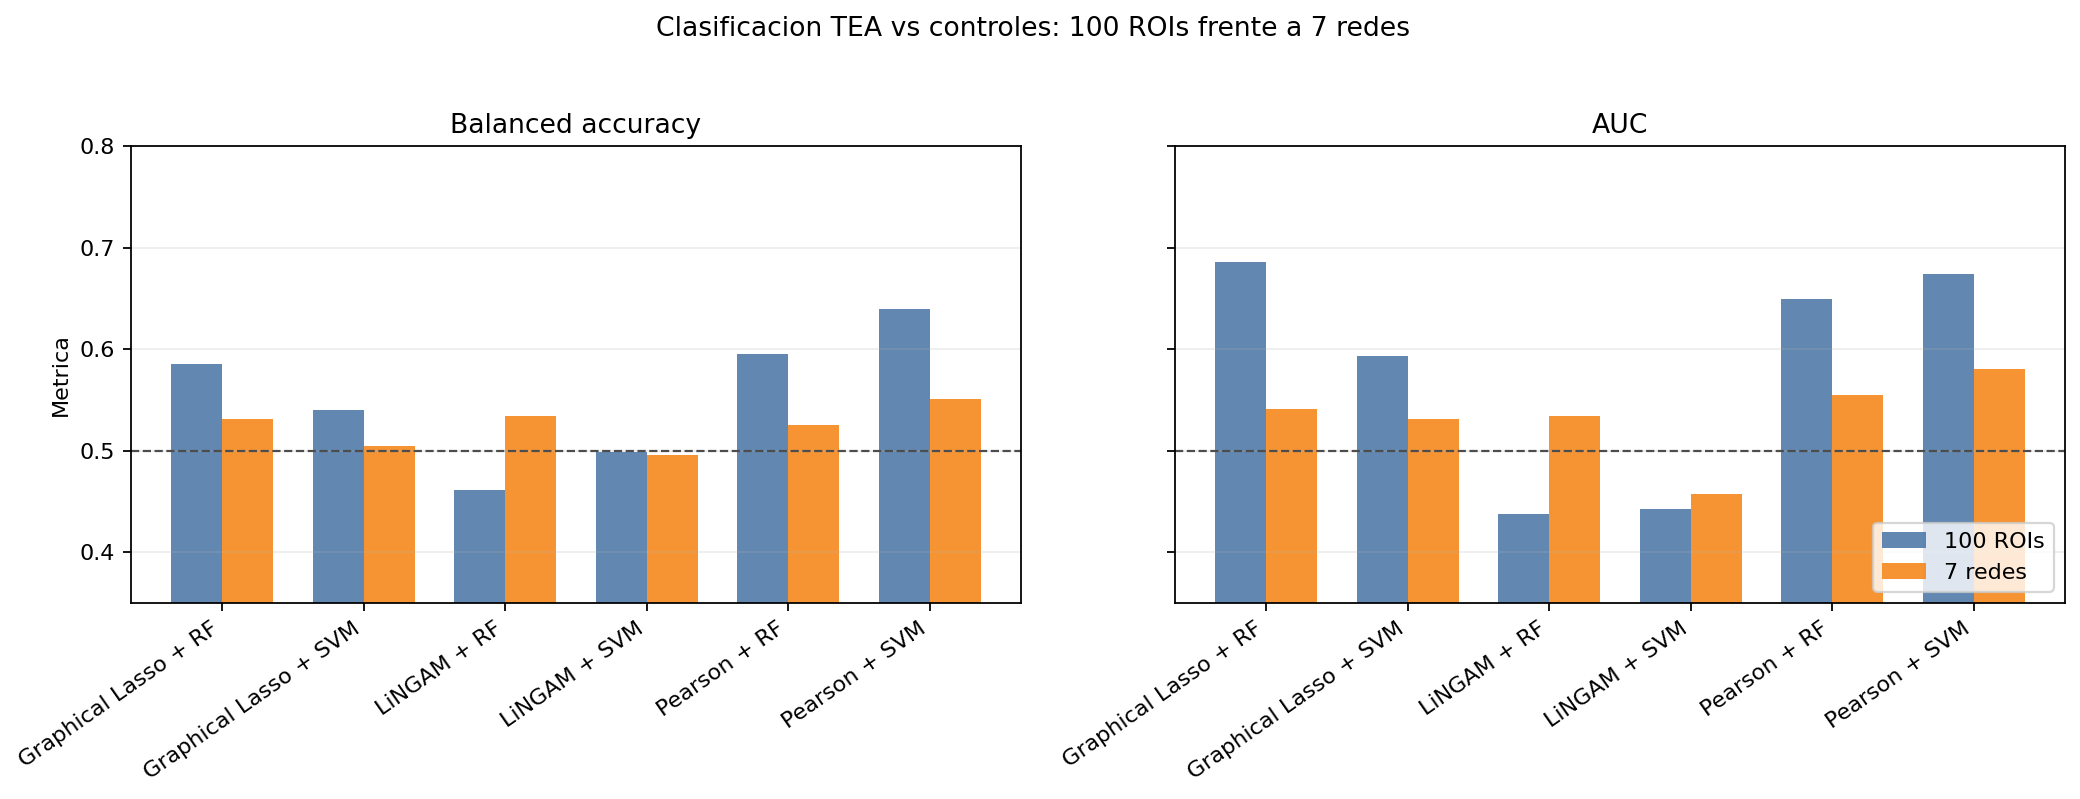

WindowsPath('C:/Users/crist/OneDrive/Escritorio/Tesis Segunda Entrega/resultados/pipeline_versiones10_lingam_resolucion/figures/comparacion_clasificacion_100rois_vs_7redes.png')

In [21]:
def plot_classification_comparison(comparison: pd.DataFrame) -> Path:
    plot_data = comparison.copy()
    plot_data["method_classifier"] = plot_data["method_label"] + " + " + plot_data["classifier"].str.upper()
    order = (
        plot_data[["method", "classifier", "method_classifier"]]
        .drop_duplicates()
        .sort_values(["method", "classifier"])["method_classifier"]
        .tolist()
    )

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), dpi=160, sharey=True)
    metrics = [("balanced_accuracy", "Balanced accuracy"), ("auc", "AUC")]
    colors = {"100 ROIs": "#4C78A8", "7 redes": "#F58518"}
    x = np.arange(len(order))
    width = 0.36

    for ax, (metric, title) in zip(axes, metrics):
        for offset, resolution in [(-width / 2, "100 ROIs"), (width / 2, "7 redes")]:
            values = []
            for label in order:
                match = plot_data[(plot_data["method_classifier"] == label) & (plot_data["resolution"] == resolution)]
                values.append(float(match[metric].iloc[0]) if not match.empty else np.nan)
            ax.bar(x + offset, values, width=width, label=resolution, color=colors[resolution], alpha=0.88)
        ax.axhline(0.5, color="0.3", linestyle="--", linewidth=1.0)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(order, rotation=35, ha="right")
        ax.set_ylim(0.35, 0.8)
        ax.grid(axis="y", alpha=0.22)
    axes[0].set_ylabel("Metrica")
    axes[1].legend(loc="lower right")
    fig.suptitle("Clasificacion TEA vs controles: 100 ROIs frente a 7 redes", y=1.03)
    fig.tight_layout()
    path = FIG_DIR / "comparacion_clasificacion_100rois_vs_7redes.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


classification_comparison_fig = plot_classification_comparison(comparison)
classification_comparison_fig


## 6. Matrices promedio 7x7 y diferencias TEA - controles

Aqui se generan las matrices promedio por grupo y la diferencia TEA - Control. En Pearson y Graphical Lasso las matrices son simetricas. En LiNGAM la matriz es dirigida: filas como origen y columnas como destino.


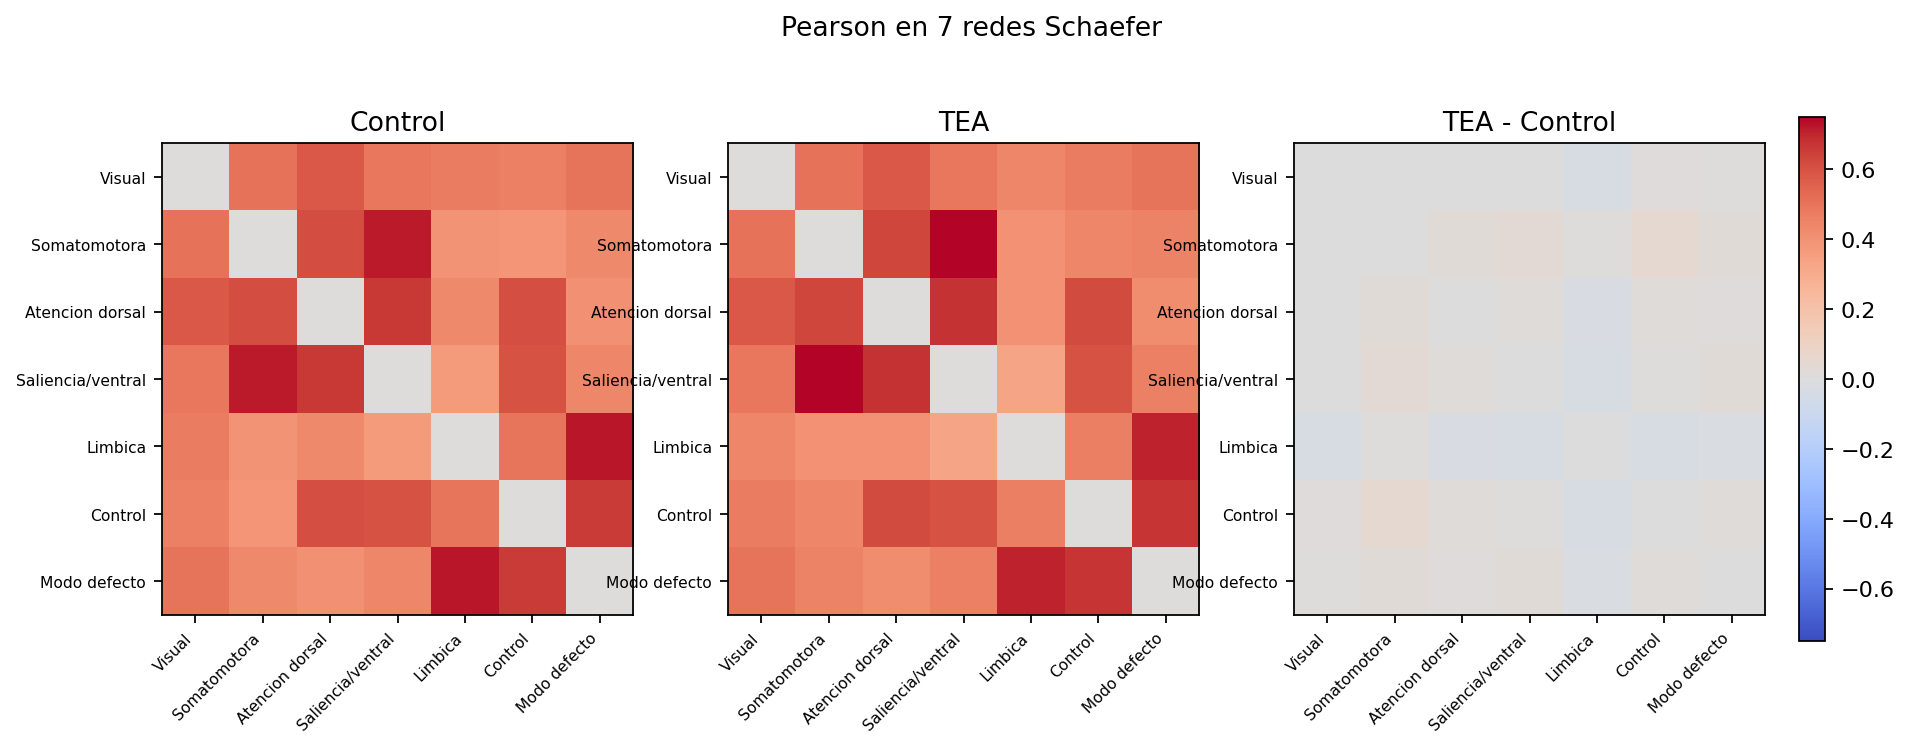

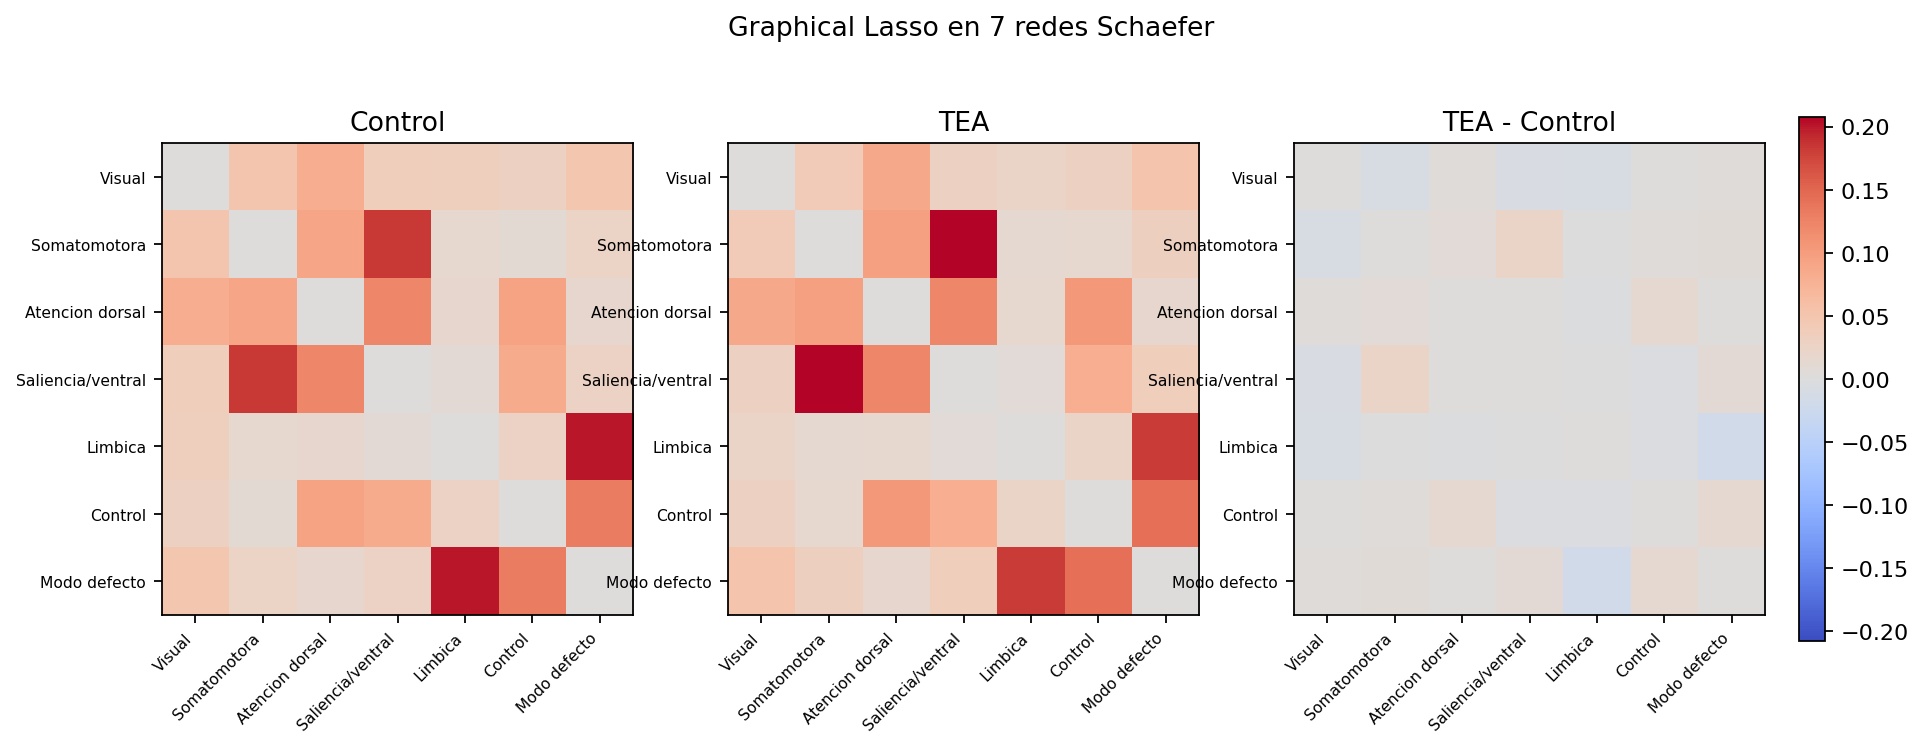

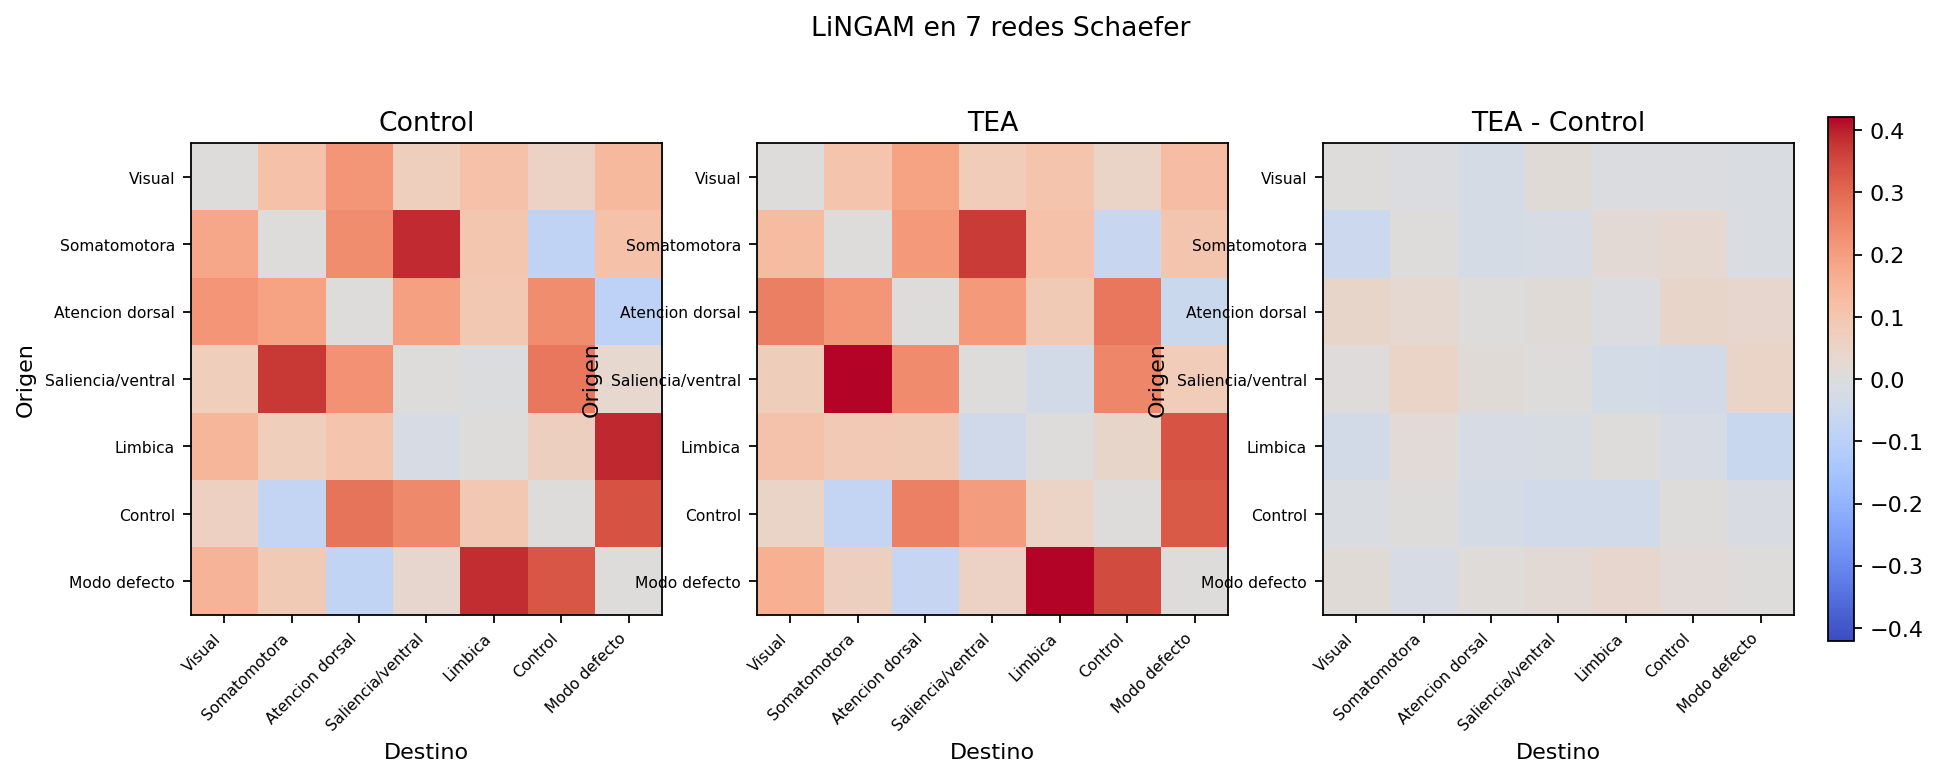

[WindowsPath('C:/Users/crist/OneDrive/Escritorio/Tesis Segunda Entrega/resultados/pipeline_versiones10_lingam_resolucion/figures/matrices_7redes_pearson.png'),
 WindowsPath('C:/Users/crist/OneDrive/Escritorio/Tesis Segunda Entrega/resultados/pipeline_versiones10_lingam_resolucion/figures/matrices_7redes_graphical_lasso.png'),
 WindowsPath('C:/Users/crist/OneDrive/Escritorio/Tesis Segunda Entrega/resultados/pipeline_versiones10_lingam_resolucion/figures/matrices_7redes_lingam.png')]

In [22]:
def matrix_for_plot(matrix: np.ndarray, method: str) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float).copy()
    np.fill_diagonal(matrix, 0.0)
    return matrix


def save_group_matrices_7(datasets_7: dict[str, dict[str, object]]) -> dict[str, dict[str, np.ndarray]]:
    group_mats: dict[str, dict[str, np.ndarray]] = {}
    for method, data in datasets_7.items():
        matrices = np.asarray(data["matrices"], dtype=float)
        y = np.asarray(data["y"], dtype=int)
        control = np.nanmean(matrices[y == 0], axis=0)
        tea = np.nanmean(matrices[y == 1], axis=0)
        diff = tea - control
        group_mats[method] = {"control": control, "tea": tea, "diff_tea_minus_control": diff}

        method_out = OUT_V10 / "matrices_promedio_7redes" / method
        method_out.mkdir(parents=True, exist_ok=True)
        for name, matrix in group_mats[method].items():
            np.save(method_out / f"{name}.npy", matrix.astype(np.float32))
            pd.DataFrame(matrix, index=NETWORK_ORDER, columns=NETWORK_ORDER).to_csv(method_out / f"{name}.csv")
    return group_mats


def plot_group_matrices_7(group_mats: dict[str, dict[str, np.ndarray]]) -> list[Path]:
    paths = []
    labels = [NETWORK_LABELS[network] for network in NETWORK_ORDER]
    for method, mats in group_mats.items():
        matrices = [
            ("Control", matrix_for_plot(mats["control"], method)),
            ("TEA", matrix_for_plot(mats["tea"], method)),
            ("TEA - Control", matrix_for_plot(mats["diff_tea_minus_control"], method)),
        ]
        vmax = max(float(np.nanpercentile(np.abs(matrix), 98)) for _, matrix in matrices)
        vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0

        fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.25), dpi=160)
        for ax, (title, matrix) in zip(axes, matrices):
            image = ax.imshow(matrix, cmap="coolwarm", vmin=-vmax, vmax=vmax)
            ax.set_title(title)
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(np.arange(len(labels)))
            ax.set_yticklabels(labels, fontsize=7)
            if not METHODS_V10[method]["symmetric"]:
                ax.set_xlabel("Destino")
                ax.set_ylabel("Origen")
        fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.022, pad=0.02)
        fig.suptitle(f"{METHODS_V10[method]['label']} en 7 redes Schaefer", y=1.03)
        path = FIG_DIR / f"matrices_7redes_{method}.png"
        fig.savefig(path, bbox_inches="tight")
        plt.show()
        paths.append(path)
    return paths


group_mats_7 = save_group_matrices_7(datasets_7)
matrix_figures_7 = plot_group_matrices_7(group_mats_7)
matrix_figures_7


In [23]:
def edge_rows_for_method(method: str, matrices: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    rows = []
    n = matrices.shape[1]
    if METHODS_V10[method]["symmetric"]:
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    else:
        pairs = [(i, j) for i in range(n) for j in range(n) if i != j]

    control = matrices[y == 0]
    tea = matrices[y == 1]
    for i, j in pairs:
        values_control = control[:, i, j]
        values_tea = tea[:, i, j]
        mean_control = float(np.nanmean(values_control))
        mean_tea = float(np.nanmean(values_tea))
        diff = mean_tea - mean_control
        rows.append(
            {
                "method": method,
                "method_label": METHODS_V10[method]["label"],
                "resolution": "7 redes",
                "directed": not METHODS_V10[method]["symmetric"],
                "network_origen": NETWORK_ORDER[i],
                "network_destino": NETWORK_ORDER[j],
                "network_origen_label": NETWORK_LABELS[NETWORK_ORDER[i]],
                "network_destino_label": NETWORK_LABELS[NETWORK_ORDER[j]],
                "mean_control": mean_control,
                "mean_tea": mean_tea,
                "difference_tea_minus_control": float(diff),
                "abs_difference": float(abs(diff)),
                "abs_mean_control": float(abs(mean_control)),
                "abs_mean_tea": float(abs(mean_tea)),
            }
        )
    return pd.DataFrame(rows)


edge_tables = []
for method, data in datasets_7.items():
    edge_tables.append(edge_rows_for_method(method, np.asarray(data["matrices"]), np.asarray(data["y"])))

edges_7 = pd.concat(edge_tables, ignore_index=True)
edges_7.to_csv(TABLE_DIR / "conexiones_7redes_todas.csv", index=False)

top_edges_7 = (
    edges_7.sort_values(["method", "abs_difference"], ascending=[True, False])
    .groupby("method", group_keys=False)
    .head(20)
    .reset_index(drop=True)
)
top_edges_7.to_csv(TABLE_DIR / "top20_conexiones_7redes_por_metodo.csv", index=False)

display(
    top_edges_7[
        [
            "method_label",
            "directed",
            "network_origen_label",
            "network_destino_label",
            "mean_control",
            "mean_tea",
            "difference_tea_minus_control",
            "abs_difference",
        ]
    ]
)


,method_label,directed,network_origen_label,network_destino_label,mean_control,mean_tea,difference_tea_minus_control,abs_difference
0,Graphical Lasso,False,Somatomotora,Saliencia/ventral,0.183620,0.207523,0.023903,0.023903
1,Graphical Lasso,False,Limbica,Modo defecto,0.199905,0.181996,-0.017910,0.017910
2,Graphical Lasso,False,Atencion dorsal,Control,0.092531,0.105131,0.012600,0.012600
3,Graphical Lasso,False,Control,Modo defecto,0.130657,0.142117,0.011460,0.011460
4,Graphical Lasso,False,Visual,Limbica,0.033354,0.023696,-0.009658,0.009658
5,Graphical Lasso,False,Visual,Somatomotora,0.049798,0.040485,-0.009313,0.009313
6,Graphical Lasso,False,Saliencia/ventral,Modo defecto,0.026271,0.034964,0.008694,0.008694
7,Graphical Lasso,False,Visual,Saliencia/ventral,0.034657,0.027627,-0.007029,0.007029
8,Graphical Lasso,False,Somatomotora,Atencion dorsal,0.089298,0.095933,0.006635,0.006635
9,Graphical Lasso,False,Somatomotora,Modo defecto,0.025103,0.031359,0.006256,0.006256


## 7. Contexto de literatura por red

Esta celda no crea resultados nuevos. Solo toma las conexiones calculadas arriba y agrega una lectura por red para revisar si las conexiones mas distintas involucran sistemas frecuentemente discutidos en TEA, como modo por defecto, saliencia/atencion ventral, control/frontoparietal, atencion dorsal, visual y somatomotor.


In [24]:
NETWORK_CONTEXT = {
    "Default": {
        "level": "alta",
        "note": "La red de modo por defecto aparece con frecuencia en estudios de conectividad funcional en TEA.",
        "references": "Assaf et al. 2010; Di Martino et al. 2014; Hull et al. 2017",
    },
    "SalVentAttn": {
        "level": "alta",
        "note": "La red de saliencia/atencion ventral se relaciona con insula y deteccion de relevancia, sistemas reportados en ABIDE.",
        "references": "Di Martino et al. 2014; Hull et al. 2017",
    },
    "Cont": {
        "level": "moderada",
        "note": "La red de control/frontoparietal se interpreta dentro de alteraciones distribuidas de redes corticales.",
        "references": "Di Martino et al. 2014; Hull et al. 2017",
    },
    "DorsAttn": {
        "level": "moderada",
        "note": "La red de atencion dorsal es relevante para sistemas task-positive y control atencional.",
        "references": "Hull et al. 2017",
    },
    "SomMot": {
        "level": "descriptiva",
        "note": "La red somatomotora puede aparecer en TEA por diferencias sensoriomotoras, pero debe interpretarse con cuidado.",
        "references": "Hull et al. 2017",
    },
    "Vis": {
        "level": "descriptiva",
        "note": "La red visual puede aparecer en patrones de conectividad en TEA, aunque no debe leerse como marcador aislado.",
        "references": "Hull et al. 2017",
    },
    "Limbic": {
        "level": "moderada",
        "note": "La red limbica puede relacionarse con procesamiento socioemocional, con cautela por la resolucion del atlas.",
        "references": "Di Martino et al. 2014; Hull et al. 2017",
    },
}


def context_for_edge(network_a: str, network_b: str) -> dict[str, str]:
    contexts = [NETWORK_CONTEXT.get(network) for network in [network_a, network_b]]
    contexts = [context for context in contexts if context is not None]
    if not contexts:
        return {
            "literature_alignment": "sin_mapeo",
            "literature_note": "No hay contexto de red disponible.",
            "references": "",
        }

    levels = [context["level"] for context in contexts]
    if "alta" in levels:
        level = "alta"
    elif "moderada" in levels:
        level = "moderada"
    else:
        level = "descriptiva"

    notes = " ".join(dict.fromkeys(context["note"] for context in contexts))
    references = "; ".join(sorted({ref.strip() for context in contexts for ref in context["references"].split(";")}))
    return {
        "literature_alignment": level,
        "literature_note": notes,
        "references": references,
    }


context_rows = []
for row in top_edges_7.itertuples(index=False):
    context = context_for_edge(str(row.network_origen), str(row.network_destino))
    context_rows.append(context)

top_edges_7_literature = pd.concat([top_edges_7.reset_index(drop=True), pd.DataFrame(context_rows)], axis=1)
top_edges_7_literature.to_csv(TABLE_DIR / "top20_conexiones_7redes_contexto_literatura.csv", index=False)

display(
    top_edges_7_literature[
        [
            "method_label",
            "network_origen_label",
            "network_destino_label",
            "difference_tea_minus_control",
            "literature_alignment",
            "literature_note",
            "references",
        ]
    ]
)


,method_label,network_origen_label,network_destino_label,difference_tea_minus_control,literature_alignment,literature_note,references
0,Graphical Lasso,Somatomotora,Saliencia/ventral,0.023903,alta,La red somatomotora puede aparecer en TEA por ...,Di Martino et al. 2014; Hull et al. 2017
1,Graphical Lasso,Limbica,Modo defecto,-0.017910,alta,La red limbica puede relacionarse con procesam...,Assaf et al. 2010; Di Martino et al. 2014; Hul...
2,Graphical Lasso,Atencion dorsal,Control,0.012600,moderada,La red de atencion dorsal es relevante para si...,Di Martino et al. 2014; Hull et al. 2017
3,Graphical Lasso,Control,Modo defecto,0.011460,alta,La red de control/frontoparietal se interpreta...,Assaf et al. 2010; Di Martino et al. 2014; Hul...
4,Graphical Lasso,Visual,Limbica,-0.009658,moderada,La red visual puede aparecer en patrones de co...,Di Martino et al. 2014; Hull et al. 2017
5,Graphical Lasso,Visual,Somatomotora,-0.009313,descriptiva,La red visual puede aparecer en patrones de co...,Hull et al. 2017
6,Graphical Lasso,Saliencia/ventral,Modo defecto,0.008694,alta,La red de saliencia/atencion ventral se relaci...,Assaf et al. 2010; Di Martino et al. 2014; Hul...
7,Graphical Lasso,Visual,Saliencia/ventral,-0.007029,alta,La red visual puede aparecer en patrones de co...,Di Martino et al. 2014; Hull et al. 2017
8,Graphical Lasso,Somatomotora,Atencion dorsal,0.006635,moderada,La red somatomotora puede aparecer en TEA por ...,Hull et al. 2017
9,Graphical Lasso,Somatomotora,Modo defecto,0.006256,alta,La red somatomotora puede aparecer en TEA por ...,Assaf et al. 2010; Di Martino et al. 2014; Hul...


## 8. Diagnostico especifico para LiNGAM

Aqui se revisa por que LiNGAM 100x100 puede rendir bajo en clasificacion: tiene 9900 conexiones dirigidas por sujeto, mientras que LiNGAM 7x7 tiene 42. Tambien se evalua si la magnitud media de las matrices se relaciona con la cantidad de puntos temporales y con el sitio.


In [25]:
def safe_corr(a: pd.Series, b: pd.Series) -> float:
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    valid = aa.notna() & bb.notna()
    if valid.sum() < 3:
        return np.nan
    if aa[valid].std() == 0 or bb[valid].std() == 0:
        return np.nan
    return float(np.corrcoef(aa[valid], bb[valid])[0, 1])


base_matrix_summary_path = BASE_RESULTS / "resumen_matrices_conectividad.csv"
if base_matrix_summary_path.exists():
    matrix_summary_100 = pd.read_csv(base_matrix_summary_path)
    lingam_100_summary = matrix_summary_100[matrix_summary_100["method"].eq("lingam")].copy()
    lingam_100_summary["resolution"] = "100 ROIs"
else:
    lingam_100_summary = pd.DataFrame()

lingam_7_summary = matrix_summary_7[matrix_summary_7["method"].eq("lingam")].copy()
lingam_7_summary["resolution"] = "7 redes"

dimension_rows = [
    {
        "method": method,
        "resolution": "100 ROIs",
        "n_nodes": 100,
        "n_features": 100 * 99 if not METHODS_V10[method]["symmetric"] else 100 * 99 // 2,
    }
    for method in METHODS_V10
] + [
    {
        "method": method,
        "resolution": "7 redes",
        "n_nodes": 7,
        "n_features": 7 * 6 if not METHODS_V10[method]["symmetric"] else 7 * 6 // 2,
    }
    for method in METHODS_V10
]
dimension_table = pd.DataFrame(dimension_rows)
dimension_table["method_label"] = dimension_table["method"].map(lambda method: METHODS_V10[method]["label"])
dimension_table.to_csv(TABLE_DIR / "diagnostico_dimensionalidad_100rois_vs_7redes.csv", index=False)

diagnostic_rows = []
for resolution, df in [("100 ROIs", lingam_100_summary), ("7 redes", lingam_7_summary)]:
    if df.empty:
        continue
    for metric in ["density", "abs_mean", "abs_p95", "symmetry_max_abs_diff"]:
        diagnostic_rows.append(
            {
                "method": "lingam",
                "resolution": resolution,
                "metric": metric,
                "mean": float(pd.to_numeric(df[metric], errors="coerce").mean()),
                "std": float(pd.to_numeric(df[metric], errors="coerce").std()),
                "corr_with_n_timepoints": safe_corr(df[metric], df["n_timepoints"]),
            }
        )
lingam_diagnostics = pd.DataFrame(diagnostic_rows)
lingam_diagnostics.to_csv(TABLE_DIR / "diagnostico_lingam_resolucion.csv", index=False)

site_frames = []
for resolution, df in [("100 ROIs", lingam_100_summary), ("7 redes", lingam_7_summary)]:
    if df.empty:
        continue
    tmp = (
        df.groupby("site", as_index=False)
        .agg(
            n_subjects=("file_id", "nunique"),
            n_timepoints_mean=("n_timepoints", "mean"),
            density_mean=("density", "mean"),
            abs_mean_mean=("abs_mean", "mean"),
            abs_p95_mean=("abs_p95", "mean"),
        )
        .assign(resolution=resolution)
    )
    site_frames.append(tmp)
lingam_site_diagnostics = pd.concat(site_frames, ignore_index=True) if site_frames else pd.DataFrame()
lingam_site_diagnostics.to_csv(TABLE_DIR / "diagnostico_lingam_por_sitio.csv", index=False)

display(dimension_table)
display(lingam_diagnostics)
display(lingam_site_diagnostics.sort_values(["resolution", "abs_mean_mean"], ascending=[True, False]).head(12))


,method,resolution,n_nodes,n_features,method_label
0,pearson,100 ROIs,100,4950,Pearson
1,graphical_lasso,100 ROIs,100,4950,Graphical Lasso
2,lingam,100 ROIs,100,9900,LiNGAM
3,pearson,7 redes,7,21,Pearson
4,graphical_lasso,7 redes,7,21,Graphical Lasso
5,lingam,7 redes,7,42,LiNGAM


,method,resolution,metric,mean,std,corr_with_n_timepoints
0,lingam,100 ROIs,density,0.371040,0.024113,-0.553894
1,lingam,100 ROIs,abs_mean,0.025408,0.014645,0.632852
2,lingam,100 ROIs,abs_p95,0.120535,0.076207,0.631972
3,lingam,100 ROIs,symmetry_max_abs_diff,1.000000,0.000000,NaN
4,lingam,7 redes,density,0.359119,0.048266,0.146237
5,lingam,7 redes,abs_mean,0.185496,0.028183,-0.002344
6,lingam,7 redes,abs_p95,0.786101,0.099229,0.002072
7,lingam,7 redes,symmetry_max_abs_diff,1.000000,0.000000,NaN


,site,n_subjects,n_timepoints_mean,density_mean,abs_mean_mean,abs_p95_mean,resolution
14,UM_2,34,296.000000,0.325900,0.050920,0.254106,100 ROIs
13,UM_1,86,296.000000,0.329456,0.050306,0.250925,100 ROIs
5,MAX_MUN,12,196.000000,0.296582,0.041854,0.221335,100 ROIs
2,KKI,29,152.000000,0.384500,0.024394,0.113235,100 ROIs
15,USM,67,235.940299,0.374208,0.022570,0.105282,100 ROIs
1,CMU,11,254.727273,0.389265,0.021484,0.097408,100 ROIs
10,SDSU,27,176.000000,0.386566,0.020684,0.094403,100 ROIs
6,NYU,172,176.000000,0.383438,0.020245,0.092779,100 ROIs
4,LEUVEN_2,28,246.000000,0.394834,0.019849,0.088644,100 ROIs
11,STANFORD,25,207.200000,0.384958,0.019820,0.091628,100 ROIs


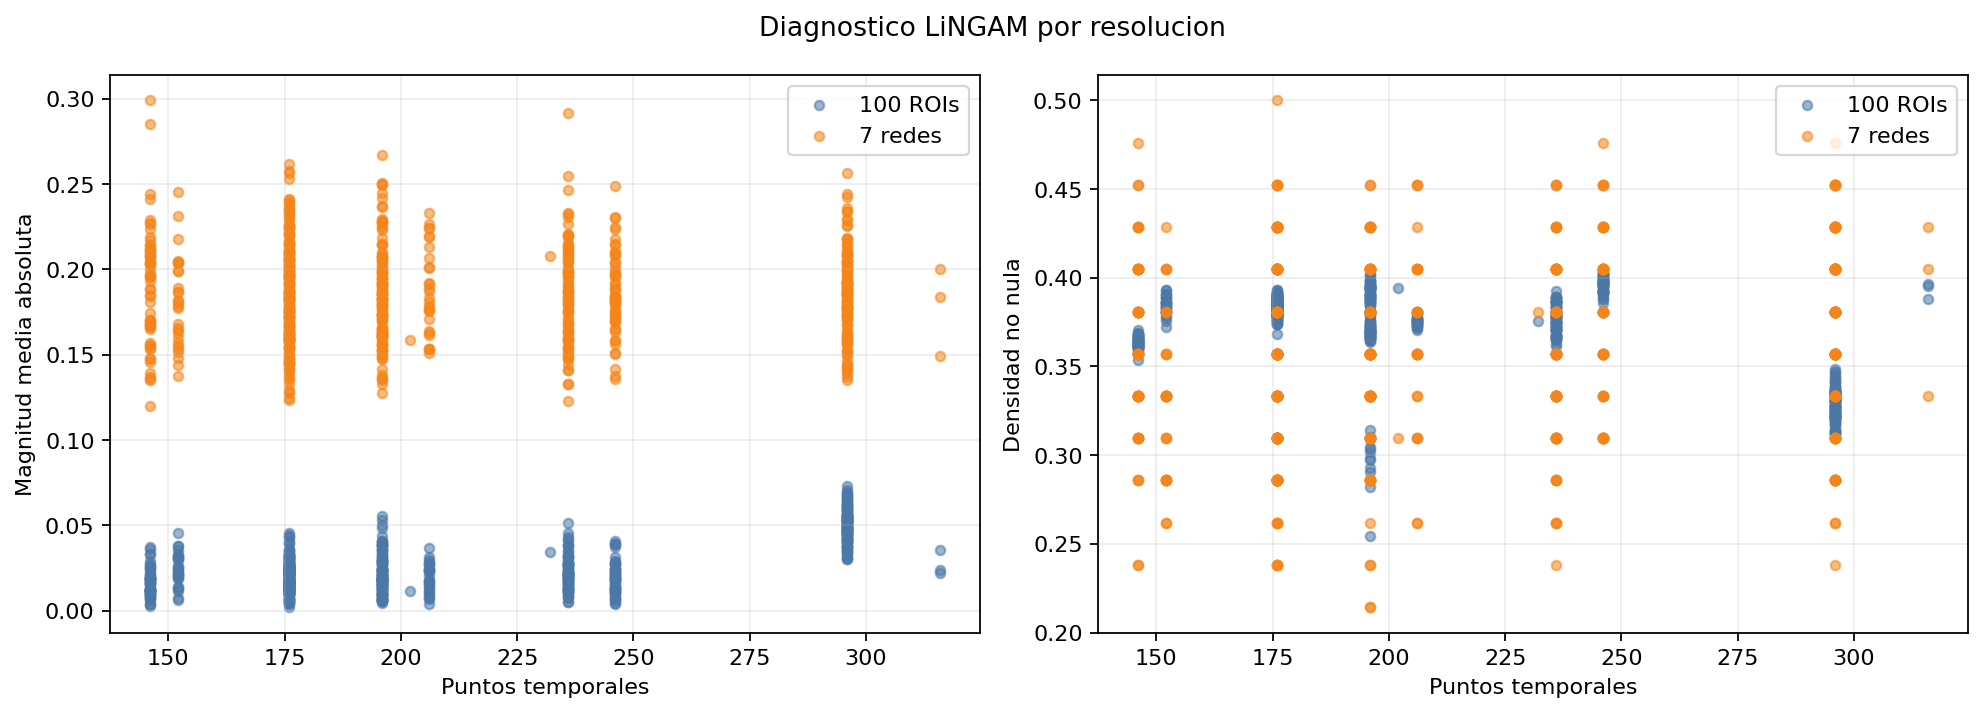

WindowsPath('C:/Users/crist/OneDrive/Escritorio/Tesis Segunda Entrega/resultados/pipeline_versiones10_lingam_resolucion/figures/diagnostico_lingam_puntos_temporales.png')

In [26]:
def plot_lingam_temporal_diagnostic(lingam_100_summary: pd.DataFrame, lingam_7_summary: pd.DataFrame) -> Path | None:
    frames = []
    if not lingam_100_summary.empty:
        frames.append(lingam_100_summary[["file_id", "site", "n_timepoints", "abs_mean", "density", "resolution"]])
    if not lingam_7_summary.empty:
        frames.append(lingam_7_summary[["file_id", "site", "n_timepoints", "abs_mean", "density", "resolution"]])
    if not frames:
        return None
    plot_data = pd.concat(frames, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), dpi=160)
    colors = {"100 ROIs": "#4C78A8", "7 redes": "#F58518"}
    for resolution, group in plot_data.groupby("resolution"):
        axes[0].scatter(group["n_timepoints"], group["abs_mean"], s=18, alpha=0.55, label=resolution, color=colors.get(resolution))
        axes[1].scatter(group["n_timepoints"], group["density"], s=18, alpha=0.55, label=resolution, color=colors.get(resolution))
    axes[0].set_xlabel("Puntos temporales")
    axes[0].set_ylabel("Magnitud media absoluta")
    axes[1].set_xlabel("Puntos temporales")
    axes[1].set_ylabel("Densidad no nula")
    for ax in axes:
        ax.grid(alpha=0.22)
        ax.legend()
    fig.suptitle("Diagnostico LiNGAM por resolucion")
    fig.tight_layout()
    path = FIG_DIR / "diagnostico_lingam_puntos_temporales.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


lingam_temporal_fig = plot_lingam_temporal_diagnostic(lingam_100_summary, lingam_7_summary)
lingam_temporal_fig


## 9. Estabilidad de conexiones LiNGAM 7x7 por remuestreo de sujetos

Esta celda mide si las conexiones LiNGAM con mayor diferencia TEA - Control se mantienen cuando se remuestrean sujetos dentro de cada grupo. No vuelve a ajustar LiNGAM; evalua estabilidad del contraste grupal sobre las matrices ya calculadas.


In [27]:
def bootstrap_lingam_edge_stability(
    matrices: np.ndarray,
    y: np.ndarray,
    n_boot: int = 500,
    top_n: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    n = matrices.shape[1]
    pairs = [(i, j) for i in range(n) for j in range(n) if i != j]
    control_idx = np.where(y == 0)[0]
    tea_idx = np.where(y == 1)[0]
    counts = np.zeros(len(pairs), dtype=int)

    observed_diff = np.array([
        float(np.nanmean(matrices[tea_idx, i, j]) - np.nanmean(matrices[control_idx, i, j]))
        for i, j in pairs
    ])

    for _ in range(n_boot):
        sampled_control = rng.choice(control_idx, size=len(control_idx), replace=True)
        sampled_tea = rng.choice(tea_idx, size=len(tea_idx), replace=True)
        boot_diff = np.array([
            float(np.nanmean(matrices[sampled_tea, i, j]) - np.nanmean(matrices[sampled_control, i, j]))
            for i, j in pairs
        ])
        top_idx = np.argsort(np.abs(boot_diff))[-top_n:]
        counts[top_idx] += 1

    rows = []
    for edge_idx, (i, j) in enumerate(pairs):
        rows.append(
            {
                "network_origen": NETWORK_ORDER[i],
                "network_destino": NETWORK_ORDER[j],
                "network_origen_label": NETWORK_LABELS[NETWORK_ORDER[i]],
                "network_destino_label": NETWORK_LABELS[NETWORK_ORDER[j]],
                "observed_difference_tea_minus_control": observed_diff[edge_idx],
                "observed_abs_difference": abs(observed_diff[edge_idx]),
                "selection_count_top_n": int(counts[edge_idx]),
                "selection_rate_top_n": float(counts[edge_idx] / n_boot),
                "n_boot": int(n_boot),
                "top_n": int(top_n),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["selection_rate_top_n", "observed_abs_difference"],
        ascending=False,
    ).reset_index(drop=True)


lingam_stability_7 = bootstrap_lingam_edge_stability(
    np.asarray(datasets_7["lingam"]["matrices"], dtype=float),
    np.asarray(datasets_7["lingam"]["y"], dtype=int),
    n_boot=500,
    top_n=10,
    random_state=RANDOM_STATE,
)
lingam_stability_7.to_csv(TABLE_DIR / "lingam_7redes_estabilidad_top_conexiones.csv", index=False)

display(lingam_stability_7.head(15))


,network_origen,network_destino,network_origen_label,network_destino_label,observed_difference_tea_minus_control,observed_abs_difference,selection_count_top_n,selection_rate_top_n,n_boot,top_n
0,Limbic,Default,Limbica,Modo defecto,-0.058664,0.058664,379,0.758,500,10
1,SalVentAttn,Default,Saliencia/ventral,Modo defecto,0.047052,0.047052,336,0.672,500,10
2,SomMot,Vis,Somatomotora,Visual,-0.049490,0.049490,333,0.666,500,10
3,SalVentAttn,SomMot,Saliencia/ventral,Somatomotora,0.048588,0.048588,298,0.596,500,10
4,DorsAttn,Vis,Atencion dorsal,Visual,0.041686,0.041686,271,0.542,500,10
5,DorsAttn,Cont,Atencion dorsal,Control,0.039575,0.039575,257,0.514,500,10
6,Cont,SalVentAttn,Control,Saliencia/ventral,-0.038796,0.038796,254,0.508,500,10
7,Default,Limbic,Modo defecto,Limbica,0.035405,0.035405,242,0.484,500,10
8,Cont,Limbic,Control,Limbica,-0.036902,0.036902,216,0.432,500,10
9,DorsAttn,Default,Atencion dorsal,Modo defecto,0.034966,0.034966,202,0.404,500,10


## 10. Diagnostico opcional: seleccion de conexiones en LiNGAM

Esta celda permite probar si el bajo desempeno de LiNGAM 100x100 se debe principalmente a exceso de features. La seleccion se hace dentro de cada fold de validacion cruzada mediante `SelectKBest`, para evitar fuga de informacion. Por defecto queda desactivada porque puede tardar varios minutos.


In [28]:
RUN_LINGAM_FEATURE_SELECTION = False
LINGAM_K_VALUES = [20, 42, 100, 300, 500, 1000]

if RUN_LINGAM_FEATURE_SELECTION:
    from sklearn.base import clone
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.feature_selection import SelectKBest, f_classif
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        f1_score,
        precision_score,
        recall_score,
        roc_auc_score,
    )
    from sklearn.model_selection import StratifiedGroupKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    classifier_objects = {
        "svm": SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced", random_state=RANDOM_STATE),
        "rf": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    }

    def eval_with_selectkbest(X: np.ndarray, y: np.ndarray, groups: np.ndarray, classifier_name: str, k: int) -> dict[str, float | int | str]:
        k_eff = min(int(k), int(X.shape[1]))
        cv = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        y_score = np.full(len(y), np.nan)
        y_pred = np.full(len(y), -1, dtype=int)
        for train_idx, test_idx in cv.split(X, y, groups):
            estimator = Pipeline(
                [
                    ("select", SelectKBest(score_func=f_classif, k=k_eff)),
                    ("scaler", StandardScaler()),
                    ("clf", clone(classifier_objects[classifier_name])),
                ]
            )
            estimator.fit(X[train_idx], y[train_idx])
            proba = estimator.predict_proba(X[test_idx])
            classes = list(estimator.named_steps["clf"].classes_)
            y_score[test_idx] = proba[:, classes.index(1)]
            y_pred[test_idx] = (y_score[test_idx] >= 0.5).astype(int)

        return {
            "classifier": classifier_name,
            "k": int(k_eff),
            "accuracy": float(accuracy_score(y, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y, y_pred)),
            "auc": float(roc_auc_score(y, y_score)),
            "f1": float(f1_score(y, y_pred, zero_division=0)),
            "precision": float(precision_score(y, y_pred, zero_division=0)),
            "recall": float(recall_score(y, y_pred, zero_division=0)),
            "specificity": float(recall_score(y, y_pred, pos_label=0, zero_division=0)),
        }

    groups = manifest["site"].astype(str).to_numpy()
    y_100 = np.load(BASE_RESULTS / "y_lingam.npy")
    X_100 = np.load(BASE_RESULTS / "X_lingam.npy")
    y_7 = np.asarray(datasets_7["lingam"]["y"], dtype=int)
    X_7 = np.asarray(datasets_7["lingam"]["X"], dtype=np.float32)

    rows = []
    for resolution, X, y in [("100 ROIs", X_100, y_100), ("7 redes", X_7, y_7)]:
        for classifier in CLASSIFIERS_V10:
            for k in LINGAM_K_VALUES:
                if k <= X.shape[1]:
                    rows.append({"resolution": resolution, **eval_with_selectkbest(X, y, groups, classifier, k)})

    lingam_feature_selection = pd.DataFrame(rows)
    lingam_feature_selection.to_csv(TABLE_DIR / "diagnostico_lingam_selectkbest.csv", index=False)
    display(lingam_feature_selection.sort_values(["balanced_accuracy", "auc"], ascending=False))
else:
    print("RUN_LINGAM_FEATURE_SELECTION=False. Cambiar a True para probar SelectKBest dentro de la validacion cruzada.")


RUN_LINGAM_FEATURE_SELECTION=False. Cambiar a True para probar SelectKBest dentro de la validacion cruzada.


## 11. Archivos principales generados

- `tables/comparacion_clasificacion_100rois_vs_7redes.csv`: comparacion central de clasificacion.
- `tables/clasificacion_7redes_resultados.csv`: metricas 7x7 con SVM y Random Forest.
- `tables/top20_conexiones_7redes_por_metodo.csv`: conexiones mas diferentes TEA - Control por metodo.
- `tables/top20_conexiones_7redes_contexto_literatura.csv`: mismas conexiones con contexto por red.
- `tables/diagnostico_lingam_resolucion.csv`: resumen especifico de LiNGAM.
- `tables/lingam_7redes_estabilidad_top_conexiones.csv`: estabilidad por remuestreo de sujetos.
- `figures/comparacion_clasificacion_100rois_vs_7redes.png`: figura de balanced accuracy y AUC.
- `figures/matrices_7redes_*.png`: matrices promedio Control, TEA y diferencia.

Lectura recomendada para la tesis: mantener 100x100 como comparacion principal entre Pearson, Graphical Lasso y LiNGAM, y usar 7x7 como analisis por resolucion de redes para evaluar estabilidad, interpretabilidad y desempeno.


## 12. Conexiones por grupo y concordancia con literatura

Esta seccion complementa la tabla de diferencias TEA - Control. En vez de ordenar solo por diferencia entre grupos, identifica las conexiones mas fuertes dentro de TEA y dentro de controles, y anota si las redes involucradas tienen respaldo amplio en la literatura de conectividad funcional en TEA.

La lectura correcta es descriptiva: una conexion fuerte dentro de un grupo no equivale por si sola a una diferencia diagnostica. La interpretacion principal debe combinar esta tabla con las diferencias TEA - Control y con la clasificacion.


In [29]:
# CELDA 15 - Conexiones fuertes por grupo y contexto de literatura

TOP_N_GROUP_CONNECTIONS = 10

GROUP_LABELS = {
    "Control": "Controles",
    "TEA": "TEA",
}

LEVEL_ORDER = ["alta", "moderada", "descriptiva", "sin_mapeo"]
LEVEL_LABELS = {
    "alta": "Alta",
    "moderada": "Moderada",
    "descriptiva": "Descriptiva",
    "sin_mapeo": "Sin mapeo",
}


def build_group_literature_table(edges_7: pd.DataFrame, top_n: int = TOP_N_GROUP_CONNECTIONS) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for group_name, value_col in [("Control", "mean_control"), ("TEA", "mean_tea")]:
        tmp = edges_7.copy()
        tmp["group"] = group_name
        tmp["group_label"] = GROUP_LABELS[group_name]
        tmp["mean_weight"] = tmp[value_col].astype(float)
        tmp["abs_weight"] = tmp["mean_weight"].abs()
        tmp = (
            tmp.sort_values(["method", "abs_weight"], ascending=[True, False])
            .groupby("method", group_keys=False)
            .head(top_n)
            .reset_index(drop=True)
        )
        for row in tmp.to_dict("records"):
            context = context_for_edge(row["network_origen"], row["network_destino"])
            rows.append(
                {
                    "method": row["method"],
                    "method_label": row["method_label"],
                    "group": row["group"],
                    "group_label": row["group_label"],
                    "resolution": row["resolution"],
                    "directed": bool(row["directed"]),
                    "network_origen": row["network_origen"],
                    "network_destino": row["network_destino"],
                    "network_origen_label": row["network_origen_label"],
                    "network_destino_label": row["network_destino_label"],
                    "mean_weight": float(row["mean_weight"]),
                    "abs_weight": float(row["abs_weight"]),
                    "difference_tea_minus_control": float(row["difference_tea_minus_control"]),
                    **context,
                    "interpretation_scope": "Conexion fuerte dentro del grupo; no equivale por si sola a diferencia TEA-control.",
                }
            )

    top_by_group = pd.DataFrame(rows)
    top_by_group["literature_alignment"] = pd.Categorical(
        top_by_group["literature_alignment"],
        LEVEL_ORDER,
        ordered=True,
    )
    summary = (
        top_by_group.groupby(
            ["method", "method_label", "group", "group_label", "literature_alignment"],
            observed=True,
            as_index=False,
        )
        .size()
        .rename(columns={"size": "n_top_connections"})
    )
    summary["literature_alignment_label"] = summary["literature_alignment"].astype(str).map(LEVEL_LABELS)
    return top_by_group, summary


top_group_literature, summary_group_literature = build_group_literature_table(edges_7)

top_group_literature.to_csv(
    TABLE_DIR / "top10_conexiones_por_grupo_7redes_contexto_literatura.csv",
    index=False,
)
summary_group_literature.to_csv(
    TABLE_DIR / "resumen_concordancia_literatura_por_grupo_7redes.csv",
    index=False,
)

display(summary_group_literature[summary_group_literature["n_top_connections"] > 0])
display(
    top_group_literature[
        [
            "method_label",
            "group_label",
            "network_origen_label",
            "network_destino_label",
            "mean_weight",
            "difference_tea_minus_control",
            "literature_alignment",
            "references",
        ]
    ].head(20)
)


,method,method_label,group,group_label,literature_alignment,n_top_connections,literature_alignment_label
0,graphical_lasso,Graphical Lasso,Control,Controles,alta,6,Alta
1,graphical_lasso,Graphical Lasso,Control,Controles,moderada,3,Moderada
2,graphical_lasso,Graphical Lasso,Control,Controles,descriptiva,1,Descriptiva
3,graphical_lasso,Graphical Lasso,TEA,TEA,alta,6,Alta
4,graphical_lasso,Graphical Lasso,TEA,TEA,moderada,3,Moderada
5,graphical_lasso,Graphical Lasso,TEA,TEA,descriptiva,1,Descriptiva
6,lingam,LiNGAM,Control,Controles,alta,8,Alta
7,lingam,LiNGAM,Control,Controles,moderada,2,Moderada
8,lingam,LiNGAM,TEA,TEA,alta,7,Alta
9,lingam,LiNGAM,TEA,TEA,moderada,3,Moderada


,method_label,group_label,network_origen_label,network_destino_label,mean_weight,difference_tea_minus_control,literature_alignment,references
0,Graphical Lasso,Controles,Limbica,Modo defecto,0.199905,-0.017910,alta,Assaf et al. 2010; Di Martino et al. 2014; Hul...
1,Graphical Lasso,Controles,Somatomotora,Saliencia/ventral,0.183620,0.023903,alta,Di Martino et al. 2014; Hull et al. 2017
2,Graphical Lasso,Controles,Control,Modo defecto,0.130657,0.011460,alta,Assaf et al. 2010; Di Martino et al. 2014; Hul...
3,Graphical Lasso,Controles,Atencion dorsal,Saliencia/ventral,0.121915,0.000675,alta,Di Martino et al. 2014; Hull et al. 2017
4,Graphical Lasso,Controles,Atencion dorsal,Control,0.092531,0.012600,moderada,Di Martino et al. 2014; Hull et al. 2017
5,Graphical Lasso,Controles,Somatomotora,Atencion dorsal,0.089298,0.006635,moderada,Hull et al. 2017
6,Graphical Lasso,Controles,Saliencia/ventral,Control,0.084246,-0.004452,alta,Di Martino et al. 2014; Hull et al. 2017
7,Graphical Lasso,Controles,Visual,Atencion dorsal,0.082528,0.004729,moderada,Hull et al. 2017
8,Graphical Lasso,Controles,Visual,Somatomotora,0.049798,-0.009313,descriptiva,Hull et al. 2017
9,Graphical Lasso,Controles,Visual,Modo defecto,0.047095,0.003670,alta,Assaf et al. 2010; Di Martino et al. 2014; Hul...
